# Car AI Project - EDA


#### Introduction
This notebook explores the structure, quality, and relationships within the dataset before any modeling steps are performed. The goal of the EDA is to understand the distribution of each variable, identify potential data issues, and uncover patterns that may influence the target variable. Both numerical and categorical features are examined through summary statistics, visualizations, and correlation analysis. The insights gained here guide the subsequent feature engineering and modeling decisions.

In addition to analyzing existing variables, this notebook also serves as a space to experiment with potential new features. Temporary exploratory features may be created to study their behavior, distribution, and relationships with the target. These evaluations help determine whether a feature is meaningful and should be included later in the official feature engineering pipeline. This approach keeps the modeling dataset clean while allowing flexible and informed experimentation during the EDA phase.

## 1. Libraries

In [0]:
import pandas as pd
import numpy as np
import re
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns


In [0]:
# Import project configuration
import sys
import os

# Add parent directory to path to import config
sys.path.append("..")
from config import *

print("PROJECT CONFIGURATION LOADED")
print(f"\nBASE_PATH: {BASE_PATH}")
print(f"\nData Paths:")
print(f"   - RAW_DATA_PATH: {RAW_DATA_PATH}")
print(f"   - FEATURES_PATH: {FEATURES_PATH}")
print(f"   - PROCESSED_DATA_PATH: {PROCESSED_DATA_PATH}")
print(f"   - TRAIN_TEST_PATH: {TRAIN_TEST_PATH}")
print(f"   - METRICS_PATH: {METRICS_PATH}")
print(f"\nModel Path:")
print(f"   - MODEL_PATH: {MODEL_PATH}")
print(f"\nUnity Catalog:")
print(f"   - SOURCE_CSV_FILE: {SOURCE_CSV_FILE}")
print(f"   - RAW_CARS_TABLE: {RAW_CARS_TABLE}")
print(f"   - CLEANED_CARS_TABLE: {CLEANED_CARS_TABLE}")

PROJECT CONFIGURATION LOADED

BASE_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject

Data Paths:
   - RAW_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/raw
   - FEATURES_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/features
   - PROCESSED_DATA_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/processed
   - TRAIN_TEST_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/train_test
   - METRICS_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/data/metrics

Model Path:
   - MODEL_PATH: /Workspace/Users/maria.petralia@gmail.com/CarAIProject/models

Unity Catalog:
   - SOURCE_CSV_FILE: /Volumes/workspace/caraiproject/caraiproject/Cars_Datasets_2025.csv
   - RAW_CARS_TABLE: workspace.caraiproject.raw_cars_data_gathered
   - CLEANED_CARS_TABLE: workspace.caraiproject.cleaned_cars_data


## 2. Load Dataset

### 2.1 Import Delta Table in a Pandas Dataframe

In [0]:
# Import the cleaned Delta Table into pandas DataFrame
# Use config constant for source table
source_table = CLEANED_CARS_TABLE

# Read Delta Table using Spark (required for Delta format)
spark_df = spark.table(source_table)
row_count_spark = spark_df.count()

# Convert to pandas DataFrame for data manipulation
df = spark_df.toPandas()

# Display dataset information
print("DATASET INFORMATION")
print(f"\nShape: {df.shape}")

print(f"\nColumns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col:30s} ({df[col].dtype})")

display(df.head())

print(f"\nDataset ready for EDA")

DATASET INFORMATION

Shape: (1210, 21)

Columns (21):
   1. make                           (object)
   2. model                          (object)
   3. engine_description             (object)
   4. engine_displacement_cc         (float64)
   5. battery_capacity_kwh           (float64)
   6. acc_0_100_min                  (float64)
   7. acc_0_100_max                  (float64)
   8. acc_0_100_mean                 (float64)
   9. acc_0_100_is_range             (int64)
  10. acc_0_100_is_instant           (int64)
  11. is_commercial                  (int64)
  12. horsepower_min                 (float64)
  13. horsepower_max                 (float64)
  14. horsepower_mean                (float64)
  15. horsepower_is_range            (int64)
  16. top_speed_kmh                  (float64)
  17. fuel_type                      (object)
  18. seats                          (float64)
  19. torque_nm                      (int64)
  20. price_usd                      (float64)
  21. cleaning_times

make,model,engine_description,engine_displacement_cc,battery_capacity_kwh,acc_0_100_min,acc_0_100_max,acc_0_100_mean,acc_0_100_is_range,acc_0_100_is_instant,is_commercial,horsepower_min,horsepower_max,horsepower_mean,horsepower_is_range,top_speed_kmh,fuel_type,seats,torque_nm,price_usd,cleaning_timestamp
Porsche,911 Carrera S Cabriolet,3.0L Twin-Turbo Flat-6,2981.0,null,3.9,3.9,3.9,0,0,0,443.0,443.0,443.0,0,304.0,Petrol,4.0,530,129900.0,2026-05-12T07:31:45.378Z
Porsche,911 Carrera 4,3.0L Twin-Turbo Flat-6,2981.0,null,4.4,4.4,4.4,0,0,0,379.0,379.0,379.0,0,293.0,Petrol,4.0,450,113300.0,2026-05-12T07:31:45.378Z
Porsche,911 Carrera 4 GTS,3.0L Twin-Turbo Flat-6,2981.0,null,3.3,3.3,3.3,0,0,0,473.0,473.0,473.0,0,311.0,Petrol,4.0,570,137000.0,2026-05-12T07:31:45.378Z
Porsche,911 Targa 4 GTS,3.0L Twin-Turbo Flat-6,2981.0,null,3.5,3.5,3.5,0,0,0,473.0,473.0,473.0,0,307.0,Petrol,4.0,570,157300.0,2026-05-12T07:31:45.378Z
Porsche,911 Turbo Cabriolet,3.8L Twin-Turbo Flat-6,3745.0,null,2.9,2.9,2.9,0,0,0,572.0,572.0,572.0,0,320.0,Petrol,4.0,750,184100.0,2026-05-12T07:31:45.378Z



Dataset ready for EDA


In [0]:
# drop the cleaning_timestamp column
df = df.drop(columns=["cleaning_timestamp"])

## 3. EDA

### 3.1 Quick Statistics

In [0]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_displacement_cc,1062.0,3031.252354,1873.688191,1.00,1796.50,2494.0,3778.0,16100.0
battery_capacity_kwh,104.0,80.203846,48.403722,1.24,56.00,77.4,93.4,212.0
acc_0_100_min,1205.0,7.558921,3.313640,1.90,5.20,7.1,9.5,35.0
acc_0_100_max,1205.0,7.567469,3.314095,1.90,5.20,7.1,9.5,35.0
acc_0_100_mean,1205.0,7.563195,3.313276,1.90,5.20,7.1,9.5,35.0
acc_0_100_is_range,1210.0,0.009917,0.099132,0.00,0.00,0.0,0.0,1.0
acc_0_100_is_instant,1210.0,0.000000,0.000000,0.00,0.00,0.0,0.0,0.0
is_commercial,1210.0,0.018182,0.133664,0.00,0.00,0.0,0.0,1.0
horsepower_min,1210.0,303.391736,215.511522,26.00,150.00,250.0,400.0,1850.0
horsepower_max,1210.0,308.663636,213.574386,26.00,155.00,261.0,400.0,1850.0


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   make                    1210 non-null   object 
 1   model                   1210 non-null   object 
 2   engine_description      1210 non-null   object 
 3   engine_displacement_cc  1062 non-null   float64
 4   battery_capacity_kwh    104 non-null    float64
 5   acc_0_100_min           1205 non-null   float64
 6   acc_0_100_max           1205 non-null   float64
 7   acc_0_100_mean          1205 non-null   float64
 8   acc_0_100_is_range      1210 non-null   int64  
 9   acc_0_100_is_instant    1210 non-null   int64  
 10  is_commercial           1210 non-null   int64  
 11  horsepower_min          1210 non-null   float64
 12  horsepower_max          1210 non-null   float64
 13  horsepower_mean         1210 non-null   float64
 14  horsepower_is_range     1210 non-null   

**Note**: The numerical features show high variability and heterogeneous distributions, reflecting the coexistence of economy cars, performance vehicles, and commercial vehicles.
- **Price** is strongly right-skewed, with a few extreme high-end values.
- **Engine size, horsepower, torque, and acceleration** display very large ranges,
  reflecting the mix of city cars, commercial vehicles, and supercars.
- **Battery capacity** is available only for EVs, resulting in many missing values.
- **Seats** ranges from 1 to 20, indicating both sports cars and minibuses.

These patterns confirm the presence of multiple clusters and some extreme values
that should be considered in the next steps of the EDA.


### 3.2 Distributions

In [0]:
# create an EDA df
df_eda = df.copy()


#### Price Distribution Histogram

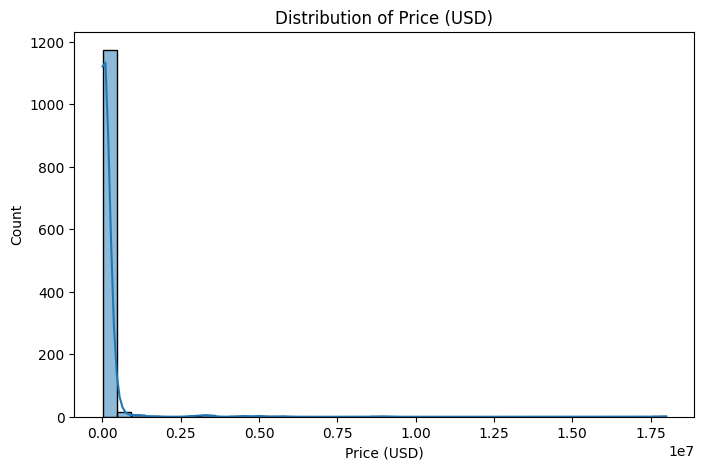

In [0]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_eda,
    x="price_usd",
    bins=40,
    kde=True
)

plt.title("Distribution of Price (USD)")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()


**Note**: The histogram of `price_usd` on a linear scale is highly right-skewed, with most vehicles concentrated below 100k USD and a small number of extreme luxury vehicles extending into the multi-million range.
This compression makes the main distribution difficult to interpret visually.
For this reason, a binned representation of price is more informative for understanding market structure.

#### Log Price Distribution Histogram

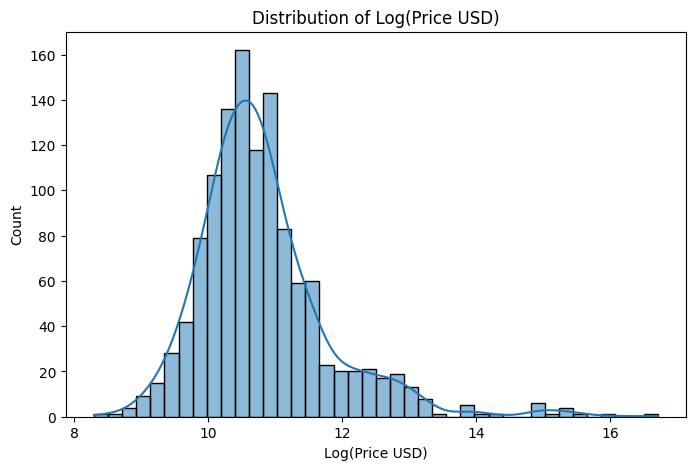

In [0]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_eda,
    x=np.log(df_eda["price_usd"]),
    bins=40,
    kde=True
)

plt.title("Distribution of Log(Price USD)")
plt.xlabel("Log(Price USD)")
plt.ylabel("Count")
plt.show()

**Note**: The log-transformed price distribution is much closer to a normal shape, with most vehicles clustered around the mid-range and fewer extreme values. This transformation reduces the impact of outliers and skewness, making patterns and relationships easier to interpret in subsequent analyses. The log scale highlights the relative differences between vehicle prices and is more suitable for statistical modeling.

#### Price Distribution by Ranges

In [0]:
bins = [
    0,
    10000,
    20000,
    30000,
    50000,
    100000,
    200000,
    300000,
    500000,
    float("inf")
]

labels = [
    "0-10k",
    "10k-20k",
    "20k-30k",
    "30k-50k",
    "50k-100k",
    "100k-200k",
    "200k-300k",
    "300k-500k",
    ">500k"
]

df_eda["price_range"] = pd.cut(
    df_eda["price_usd"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

price_distribution = df_eda["price_range"].value_counts().sort_index()
display(price_distribution)


price_range
0-10k         24
10k-20k      150
20k-30k      220
30k-50k      343
50k-100k     272
100k-200k     96
200k-300k     35
300k-500k     40
>500k         30
Name: count, dtype: int64

**Note**: Using price bins provides a clearer representation of the market structure compared to a raw histogram.
The majority of vehicles fall within the 20k-100k USD range, while only a small fraction exceeds 200k USD.
The luxury segment (>500k USD) contains very few observations, confirming a long-tailed distribution typical of automotive price data.

#### IQR Analysis of Price

In [0]:
# IQR analysis of price_usd
Q1 = df_eda["price_usd"].quantile(0.25)
Q3 = df_eda["price_usd"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_eda[(df_eda["price_usd"] < lower_bound) | (df_eda["price_usd"] > upper_bound)]
outliers_count = outliers.shape[0]
outliers_count

148

**Note**: An Interquartile Range (IQR) analysis was performed on `price_usd` to identify potential outliers.

The results show a significant number of high-end outliers (148), confirming the strong right-skewed nature of the price distribution. These extreme values are mainly concentrated in the luxury and hypercar segment.

**Key insight**  
The presence of outliers is not due to data quality issues, but reflects the natural structure of the automotive market, which includes a long tail of extremely expensive vehicles.

**Implications**  
- The price distribution is heavily skewed.
- Mean values are not representative of central tendency.
- This justifies the use of log transformation (`log_price`) in subsequent analyses and modeling steps.

#### Make Distribution

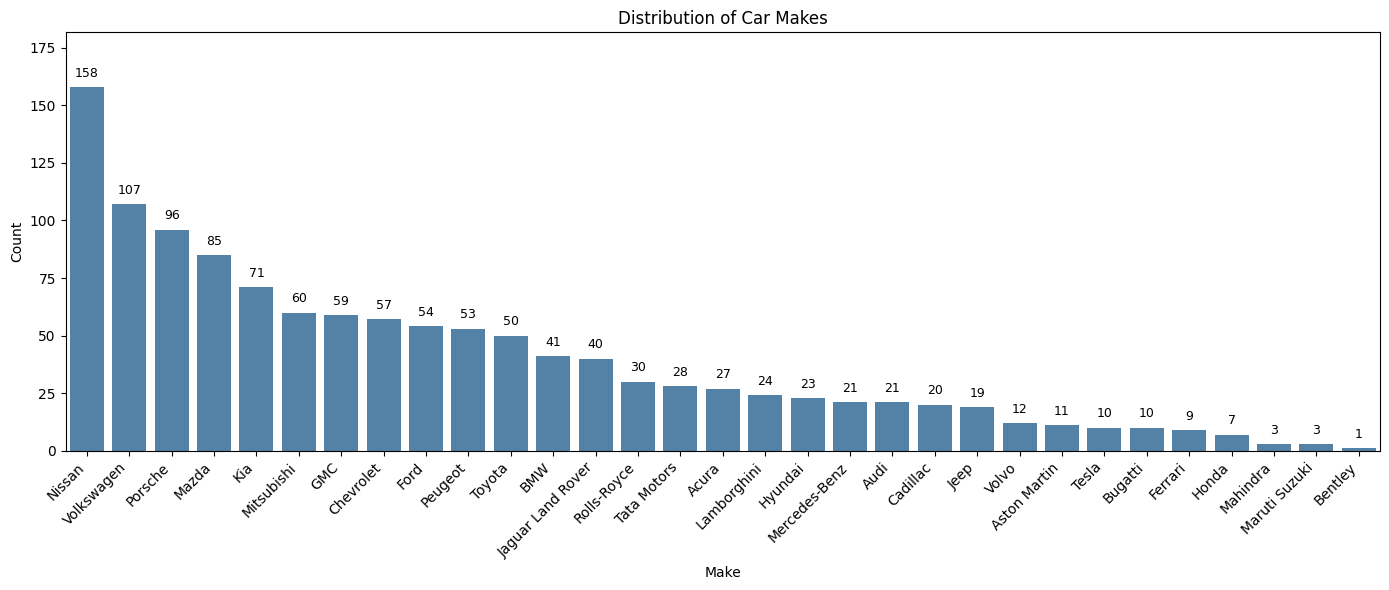

make
Nissan               158
Volkswagen           107
Porsche               96
Mazda                 85
Kia                   71
Mitsubishi            60
GMC                   59
Chevrolet             57
Ford                  54
Peugeot               53
Toyota                50
BMW                   41
Jaguar Land Rover     40
Rolls-Royce           30
Tata Motors           28
Acura                 27
Lamborghini           24
Hyundai               23
Mercedes-Benz         21
Audi                  21
Cadillac              20
Jeep                  19
Volvo                 12
Aston Martin          11
Tesla                 10
Bugatti               10
Ferrari                9
Honda                  7
Mahindra               3
Maruti Suzuki          3
Bentley                1
Name: count, dtype: int64

In [0]:
# Barplot of make distribution
# Goal:
# - Visualize the number of entries for each car make.
# - Useful to understand class imbalance and dataset structure.

make_counts = df_eda["make"].value_counts()

plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=make_counts.index,
    y=make_counts.values,
    color="steelblue"
)

# value labels
# Add value labels above each bar for clarity
for i, value in enumerate(make_counts.values):
    ax.text(
        i,
        value + (make_counts.max() * 0.02),
        str(value),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Distribution of Car Makes")
plt.ylabel("Count")
plt.xlabel("Make")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, make_counts.max() * 1.15)

plt.tight_layout()
plt.show()

# Raw distribution table
make_counts

**Note**: The dataset exhibits a pronounced imbalance in the `make` variable, with a few brands dominating the entries while many others are represented by only a handful of vehicles. This reflects the market structure, where mainstream manufacturers account for the bulk of available models, and niche or luxury brands are rare.

**Key insight**  
The strong concentration of certain makes highlights the need to account for brand effects in modeling and analysis. Rare makes may require grouping or special handling to avoid instability and sparsity in downstream tasks.

#### Number of distinct Models

In [0]:
# Number of distinct Models
distinct_model_count = df_eda["model"].nunique()
distinct_model_count

1197

**Note**: The dataset contains 1210 records and 1197 distinct car models, highlighting the high diversity of the vehicle inventory. This indicates that nearly every entry corresponds to a unique model, with only minimal duplication.

#### Seats Distribution

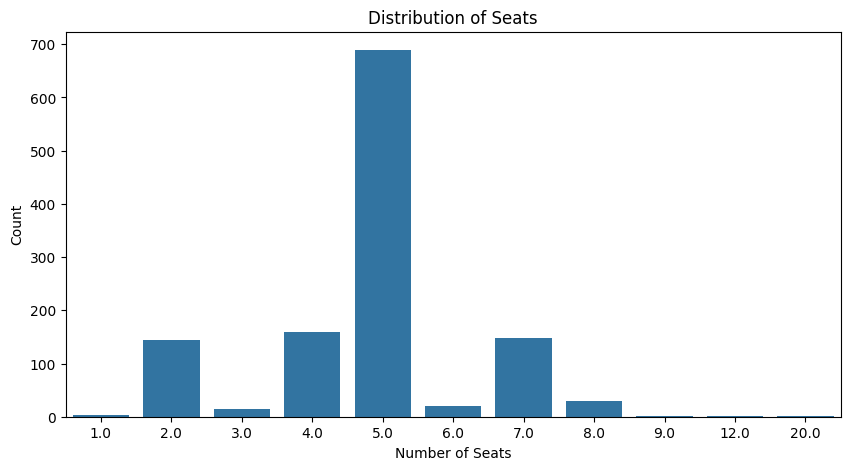

In [0]:
plt.figure(figsize=(10,5))

seat_order = sorted(df_eda["seats"].dropna().unique())

sns.countplot(
    data=df_eda,
    x="seats",
    order=seat_order
)

plt.title("Distribution of Seats")
plt.xlabel("Number of Seats")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Note**: The seat distribution is strongly concentrated around 5 seats, indicating that standard passenger cars dominate the dataset.
Other configurations (2-seaters sports cars, SUVs, vans, and minibuses) appear with much lower frequency.
The ordered representation helps preserve the structural meaning of vehicle capacity rather than treating it as a categorical variable.

#### fuel_type Distribution

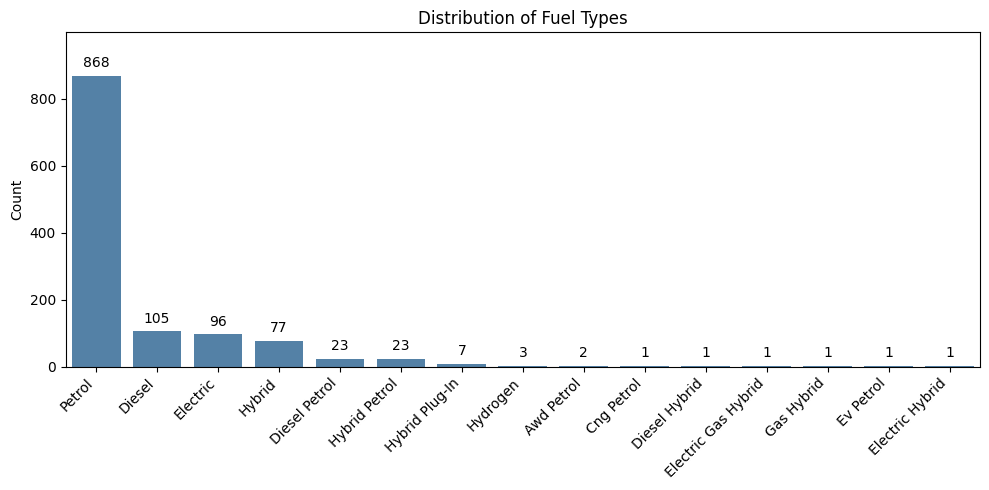

fuel_type
Petrol                 868
Diesel                 105
Electric                96
Hybrid                  77
Diesel Petrol           23
Hybrid Petrol           23
Hybrid Plug-In           7
Hydrogen                 3
Awd Petrol               2
Cng Petrol               1
Diesel Hybrid            1
Electric Gas Hybrid      1
Gas Hybrid               1
Ev Petrol                1
Electric Hybrid          1
Name: count, dtype: int64

In [0]:

# Barplot of fuel_types_clean (categorical variable)
# Goal:
# - Visualize how many entries belong to each fuel type.
# - Useful to understand class imbalance and dataset structure.

counts = df_eda["fuel_type"].value_counts()

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    color="steelblue"
)

# value labels
for i, value in enumerate(counts.values):
    ax.text(
        i,
        value + (counts.max() * 0.02),
        str(value),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Distribution of Fuel Types")
plt.ylabel("Count")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

# raw distribution table
counts

**Note**: The dataset shows a strong imbalance in `fuel_type`, with Petrol being the dominant category (868 entries), followed by Diesel (106), Electric (96), and Hybrid (77). All remaining categories are rare and account for only a few observations each.

These rare classes represent minor variations or mixed powertrains (e.g., Electric Hybrid, Diesel Hybrid, CNG Petrol) and are heavily underrepresented in the dataset.

**Key insight**  
The variable is highly imbalanced and fragmented, which makes it unsuitable for direct use in modeling without preprocessing.

**Next step**  
Fuel types will be consolidated into broader semantic groups (Petrol, Diesel, Electric, Hybrid) to improve stability and reduce sparsity in downstream models.

### 3.3 Bivariate Analysis

#### Log Transformation of Target Variable

To reduce the strong right skew in `price_usd`, a log transformation (`log1p`) was applied. This stabilizes variance and improves the interpretability of relationships between price and other numerical features.

From this point onward, `log_price` is used for correlation and bivariate analysis, while `price_usd` is kept only for interpretability and business-level distribution analysis.

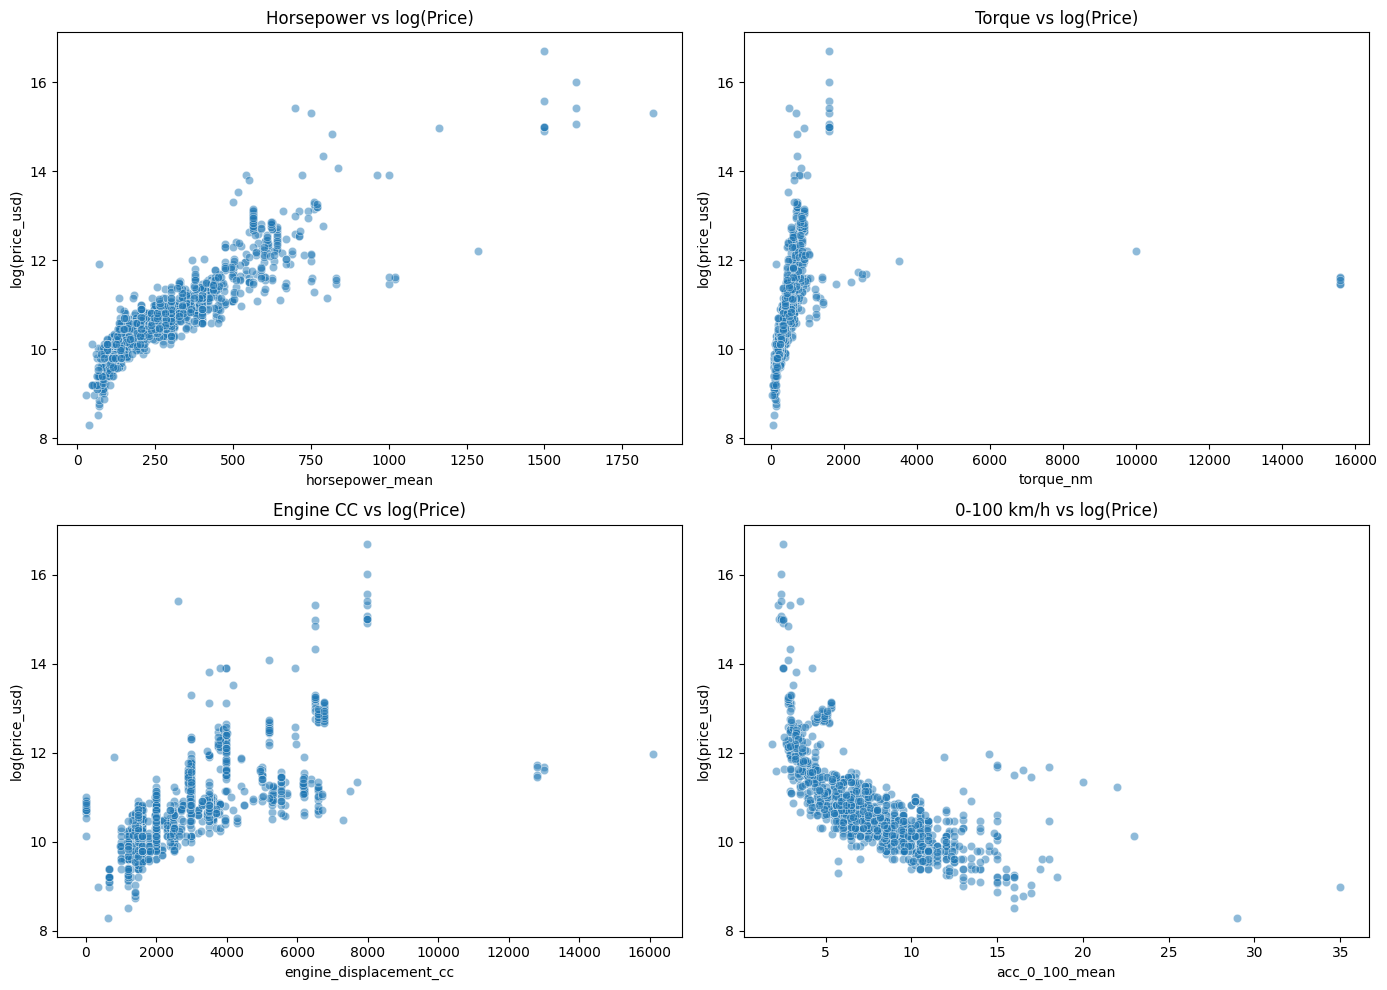

In [0]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) horsepower
sns.scatterplot(
    x=df_eda["horsepower_mean"],
    y=np.log1p(df_eda["price_usd"]),
    alpha=0.5,
    ax=axes[0,0]
)
axes[0,0].set_title("Horsepower vs log(Price)")
axes[0,0].set_xlabel("horsepower_mean")
axes[0,0].set_ylabel("log(price_usd)")

# 2) torque
sns.scatterplot(
    x=df_eda["torque_nm"],
    y=np.log1p(df_eda["price_usd"]),
    alpha=0.5,
    ax=axes[0,1]
)
axes[0,1].set_title("Torque vs log(Price)")
axes[0,1].set_xlabel("torque_nm")
axes[0,1].set_ylabel("log(price_usd)")

# 3) engine displacement
sns.scatterplot(
    x=df_eda["engine_displacement_cc"],
    y=np.log1p(df_eda["price_usd"]),
    alpha=0.5,
    ax=axes[1,0]
)
axes[1,0].set_title("Engine CC vs log(Price)")
axes[1,0].set_xlabel("engine_displacement_cc")
axes[1,0].set_ylabel("log(price_usd)")

# 4) acceleration
sns.scatterplot(
    x=df_eda["acc_0_100_mean"],
    y=np.log1p(df_eda["price_usd"]),
    alpha=0.5,
    ax=axes[1,1]
)
axes[1,1].set_title("0-100 km/h vs log(Price)")
axes[1,1].set_xlabel("acc_0_100_mean")
axes[1,1].set_ylabel("log(price_usd)")

plt.tight_layout()
plt.show()

**Note**: The scatterplots show clear and consistent relationships between vehicle performance characteristics and price when using a log-transformed scale.

- **Horsepower vs Price** shows a strong positive relationship, with higher horsepower values associated with higher vehicle prices. The distribution forms clear clusters corresponding to economy, mid-range, and high-performance vehicles.

- **Torque vs Price** follows a similar upward trend, although electric vehicles form a distinct cluster due to high torque values at relatively lower price ranges.

- **Engine Displacement vs Price** shows a weaker and more segmented relationship. This is mainly due to the coexistence of internal combustion engines and electric vehicles, where displacement is not applicable.

- **Acceleration (0-100 km/h) vs Price** shows a clear inverse relationship: lower acceleration times (faster cars) are generally associated with higher prices.

#### Key insight
Performance-related variables are strong predictors of price, while engine displacement alone is less informative due to the mixed nature of EV and ICE vehicles.


#### Engine Displacement vs Battery Capacity

**Note**: After splitting the original mixed column into `engine_displacement_cc` and `battery_capacity_kwh`,
it is useful to examine how many entries fall into each of the two resulting groups. Since the two fields are mutually exclusive by construction, this comparison helps clarify how the dataset distributes between vehicles with engine displacement and vehicles with battery capacity. The barplot below summarizes this separation.

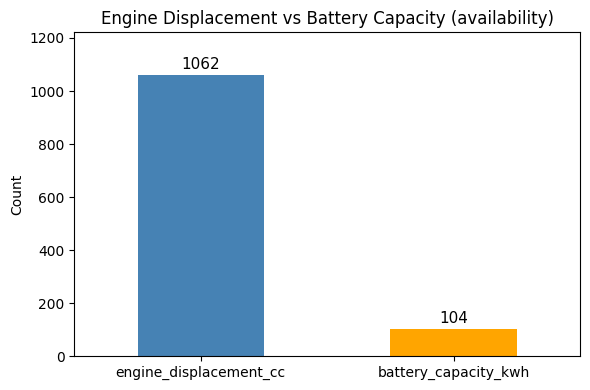

In [0]:

# Compare how many entries have engine_cc vs battery_kwh
counts = pd.Series({
    "engine_displacement_cc": df_eda["engine_displacement_cc"].notna().sum(),
    "battery_capacity_kwh": df_eda["battery_capacity_kwh"].notna().sum()
})

plt.figure(figsize=(6,4))
ax = counts.plot(kind="bar", color=["steelblue", "orange"])

# Add value labels above bars
for i, value in enumerate(counts):
    ax.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=11)

# Add padding on top so labels stay inside the plot
plt.ylim(0, counts.max() * 1.15)

plt.title("Engine Displacement vs Battery Capacity (availability)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Note**: The barplot shows the number of non-null values for engine displacement and battery capacity.

- Engine displacement is present in the vast majority of vehicles, reflecting the dominance of internal combustion engines in the dataset.
- Battery capacity appears only in a small subset of vehicles, corresponding to electric and hybrid models.

**Key insight**  
The two variables are not directly comparable within the same observations. Instead, they represent mutually exclusive technical characteristics of different vehicle architectures.

This confirms that engine_displacement_cc and battery_capacity_kwh should not be treated as correlated numerical features, but rather as indicators of underlying powertrain type.


#### Price vs Fuel Type (Linear Scale)

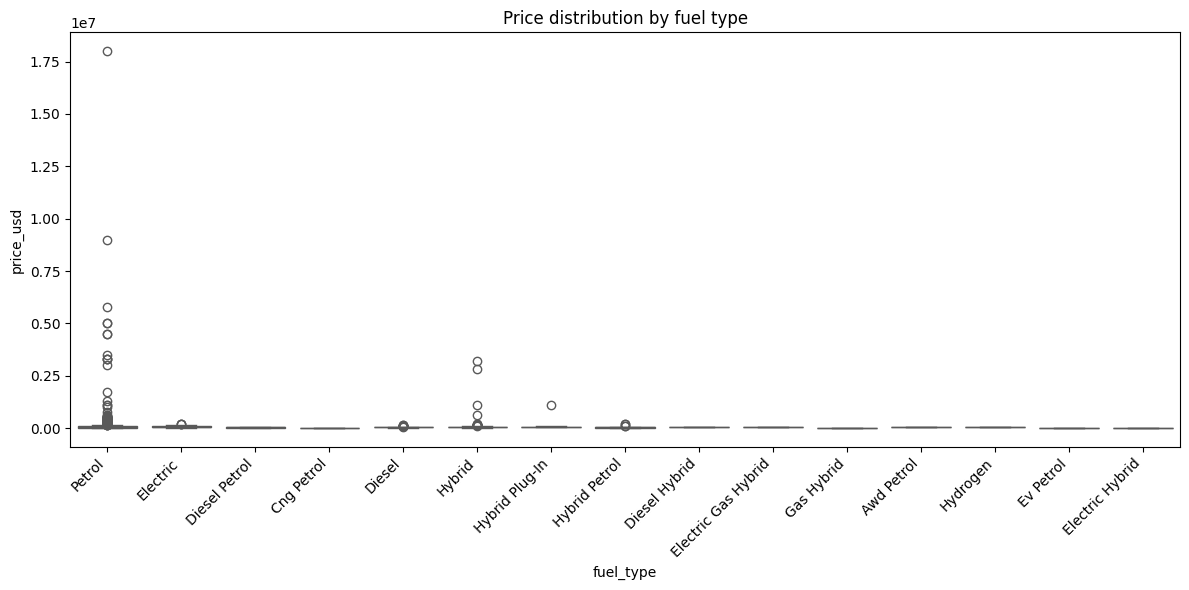

In [0]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_eda,
    x="fuel_type",
    y="price_usd",
    hue = "fuel_type",
    palette="Set2"
)
plt.xticks(rotation=45, ha="right")
plt.title("Price distribution by fuel type")
plt.tight_layout()
plt.show()

**Note**: The boxplot of price by fuel type is heavily distorted by extreme outliers, especially within Petrol and Hybrid categories. On a linear scale, the majority of observations are compressed near the bottom of the plot, making the central distribution difficult to interpret.

Despite this limitation, it is still evident that Petrol and Hybrid segments exhibit much higher variability compared to Diesel and Electric vehicles, which appear more stable and compact. This suggests strong heterogeneity within traditional and hybrid powertrains and highlights the presence of extreme high-end vehicles influencing the distribution.

In [0]:
df_eda.groupby("fuel_type")["price_usd"].describe().sort_values("count", ascending=False)

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
Petrol,868.0,160663.328341,819487.031264,4000.0,26000.0,42000.0,75550.0,18000000.0
Diesel,105.0,42115.380952,26619.595594,6200.0,27000.0,35000.0,45000.0,160000.0
Electric,96.0,68463.072917,38012.277797,11000.0,40180.0,59992.5,90125.0,200000.0
Hybrid,77.0,157415.064935,488639.070273,16000.0,38000.0,46000.0,59865.0,3200000.0
Diesel Petrol,23.0,33221.739130,19040.315040,8300.0,16000.0,33000.0,52500.0,60000.0
Hybrid Petrol,23.0,49291.521739,49517.868846,15400.0,23450.0,27100.0,47075.0,190000.0
Hybrid Plug-In,7.0,193300.000000,400114.354487,29000.0,33050.0,41000.0,58500.0,1100000.0
Hydrogen,3.0,46633.333333,7615.991947,38000.0,43750.0,49500.0,50950.0,52400.0
Awd Petrol,2.0,34500.000000,7778.174593,29000.0,31750.0,34500.0,37250.0,40000.0


**Note**: The summary statistics confirm that the price distribution is highly skewed across almost all fuel types.

- Petrol and Hybrid categories show very large gaps between mean and median, indicating strong influence of extreme outliers.
- Diesel and Electric vehicles present more compact and stable distributions.
- Rare fuel types (≤ 2 occurrences) are not statistically reliable and do not represent meaningful standalone categories.

Overall, fuel type clearly interacts with price in a non-linear way, and simple averages are not representative of the underlying distribution. This supports the need for robust transformations and possible category grouping in Feature Engineering.

#### Multivariate log_price

In [0]:
# Add log_price column
df_eda["log_price"] = np.log1p(df_eda["price_usd"])

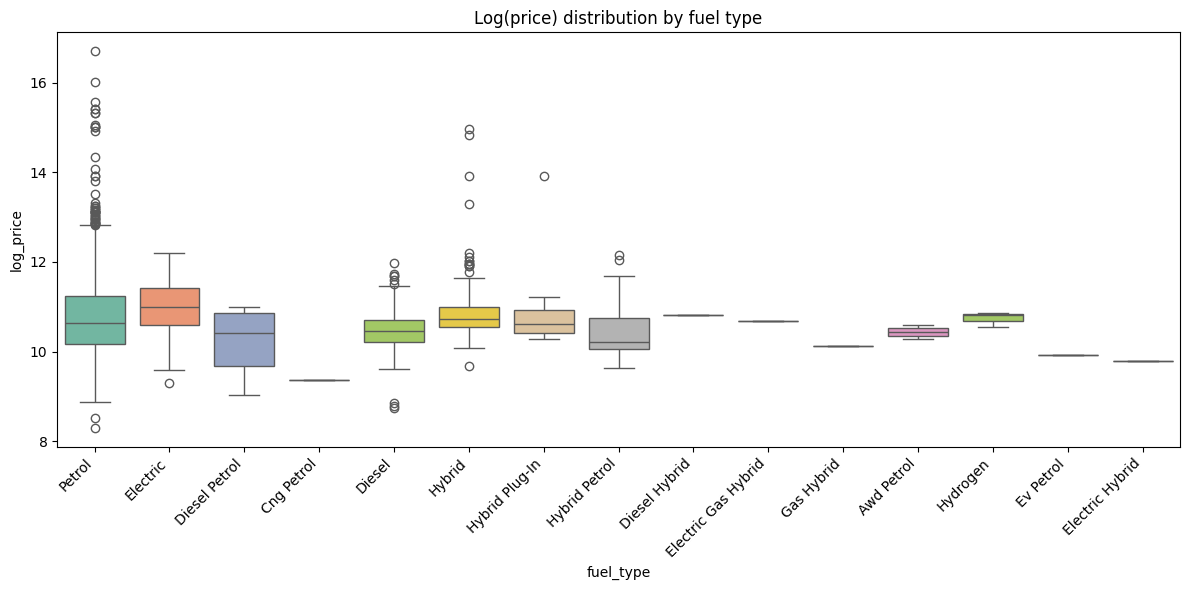

In [0]:
# Boxplot of log(price) by fuel type
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_eda,
    x="fuel_type",
    y="log_price",
    hue = "fuel_type",
    palette="Set2"
)
plt.xticks(rotation=45, ha="right")
plt.title("Log(price) distribution by fuel type")
plt.tight_layout()
plt.show()

**Note**: Applying a log transformation to price significantly improves interpretability by reducing the impact of extreme outliers.

After transformation:
- The distribution across fuel types becomes more balanced and comparable.
- Differences between categories are now visible without being dominated by a few high-value observations.
- Petrol and Hybrid remain more dispersed, while Diesel and Electric appear more compact and stable.

This confirms that the relationship between fuel type and price is non-linear and that log transformation is necessary for meaningful exploratory analysis and for improving model stability in subsequent Feature Engineering.

#### Fuel Type x Engine Displacement

In [0]:
# fuel type x engine_cc / battery_kwh
df_eda.groupby("fuel_type")["engine_displacement_cc"].describe().sort_values("count", ascending=False)

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
Petrol,840.0,3097.489286,1700.836963,360.0,1800.0,2500.0,3982.0,7993.0
Diesel,104.0,3544.230769,3079.131864,1199.0,1980.0,2349.0,3200.0,16100.0
Hybrid,69.0,1969.260870,1479.373006,1.0,1308.0,1591.0,2995.0,6498.0
Diesel Petrol,18.0,2532.833333,1159.413505,1197.0,1969.0,2150.0,2755.0,6200.0
Hybrid Petrol,18.0,2122.333333,637.537358,1396.0,1525.0,1992.5,2498.5,3500.0
Hybrid Plug-In,5.0,2574.800000,822.389628,1998.0,1999.0,2400.0,2487.0,3990.0
Awd Petrol,2.0,2239.000000,340.825469,1998.0,2118.5,2239.0,2359.5,2480.0
Cng Petrol,1.0,1199.000000,NaN,1199.0,1199.0,1199.0,1199.0,1199.0
Diesel Hybrid,1.0,3000.000000,NaN,3000.0,3000.0,3000.0,3000.0,3000.0


**Note**: The analysis of engine displacement across fuel types highlights clear structural differences between powertrain categories.

- Diesel vehicles show generally higher and more consistent engine sizes.
- Petrol vehicles exhibit the widest variability, reflecting heterogeneous engine configurations.
- Hybrid vehicles tend to have smaller engines, consistent with partial electric assistance.
- Electric vehicles correctly show missing engine displacement, confirming that this feature is not applicable.

Several rare fuel types have very low sample sizes or inconsistent values, making them unsuitable for statistical interpretation.

Overall, engine displacement behaves as a strong differentiator between traditional and electrified powertrains.


#### Battery capacity by fuel type

In [0]:
# fuel type x battery capacity
df_eda.groupby("fuel_type")["battery_capacity_kwh"].describe().sort_values("count", ascending=False)

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
Electric,92.0,88.755435,44.753617,16.00,67.50,79.2,93.40,212.00
Hybrid,5.0,13.800000,3.196091,11.40,11.40,11.6,17.30,17.30
Hybrid Petrol,4.0,17.900000,0.000000,17.90,17.90,17.9,17.90,17.90
Hydrogen,2.0,1.400000,0.226274,1.24,1.32,1.4,1.48,1.56
Petrol,1.0,32.300000,NaN,32.30,32.30,32.3,32.30,32.30
Awd Petrol,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cng Petrol,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diesel,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diesel Hybrid,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Note**: Battery capacity distribution confirms a clear separation between electric and non-electric vehicles.

- Electric vehicles form the only consistent group with meaningful battery capacity values.
- Hybrid variants show smaller battery sizes, consistent with partial electrification.
- Most ICE vehicles (Petrol and Diesel) have missing values, as expected.
- Rare fuel types appear too infrequently to derive reliable patterns.

This reinforces the idea that battery capacity is a structural feature, not a universal numeric attribute, and should be interpreted conditionally based on fuel type.

**Insight**: These two features (engine_displacement and battery_capacity) represent mutually exclusive or partially exclusive powertrain characteristics. This suggests that their predictive value depends strongly on fuel_type, and they may benefit from conditional handling or feature engineering transformations in the next stage.

### 3.5 Correlation Matrix

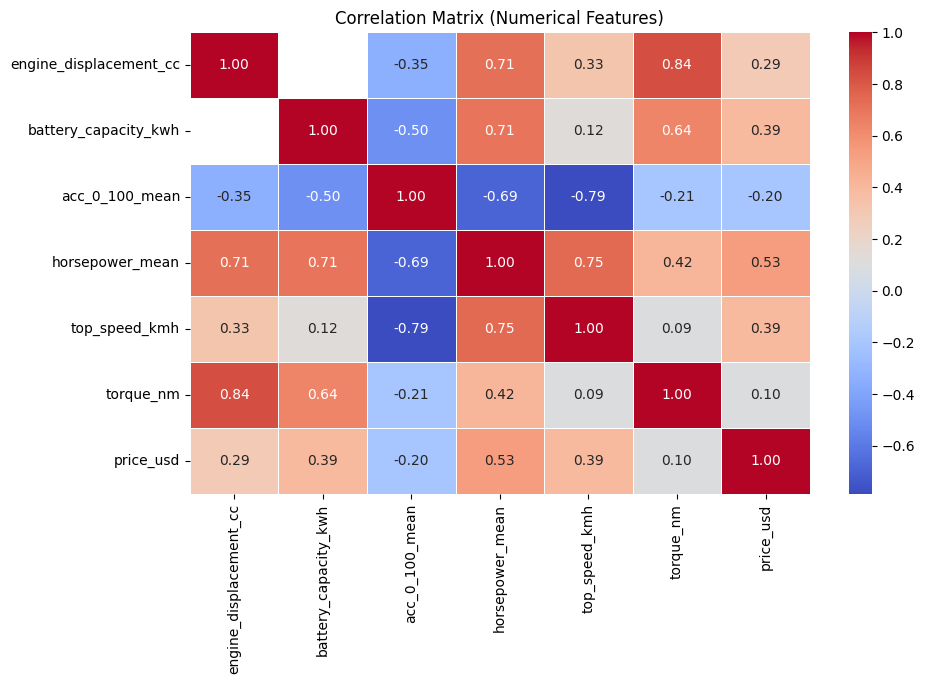

In [0]:
num_cols = [
    "engine_displacement_cc",
    "battery_capacity_kwh",
    "acc_0_100_mean",
    "horsepower_mean",
    "top_speed_kmh",
    "torque_nm",
    "price_usd"
]

corr = df_eda[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

**Note**: The correlation matrix highlights clear relationships between performance-related features and price.

- Horsepower, torque, and top speed show strong positive correlation with price, confirming that performance is a key driver of vehicle value.
- Acceleration (0-100 km/h mean) shows a negative correlation, as faster cars (lower times) tend to be more expensive.
- Engine displacement has a moderate correlation with price but is influenced by the presence of electric vehicles.
- Battery capacity shows weak correlation due to its limited presence and dependency on fuel type.

Overall, performance-related variables are more informative than structural engine characteristics.

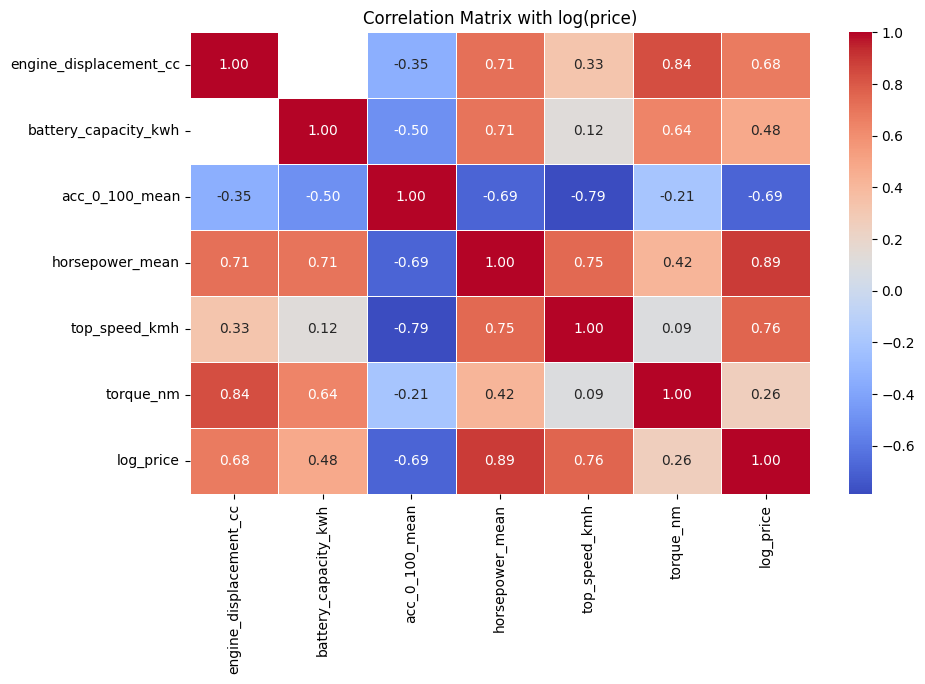

In [0]:
# Correlation Matrix with log(price) for a more stable correlation
df_eda["log_price"] = np.log1p(df_eda["price_usd"])

num_cols_log = [
    "engine_displacement_cc",
    "battery_capacity_kwh",
    "acc_0_100_mean",
    "horsepower_mean",
    "top_speed_kmh",
    "torque_nm",
    "log_price"
]

corr_log = df_eda[num_cols_log].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_log, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix with log(price)")
plt.show()


**Note**: The correlation analysis using log-transformed price provides clearer and more stable relationships between variables and target.

- Engine displacement shows a moderate positive correlation with price (0.68), confirming its relevance for traditional combustion vehicles.
- Battery capacity also shows a moderate positive correlation (0.48), reflecting its importance in electric and hybrid vehicles, although limited by data sparsity.
- Horsepower exhibits the strongest correlation with price (0.89), making it the most influential single predictor in the dataset.
- Acceleration (0-100 km/h mean) shows a strong negative correlation (-0.69), indicating that faster cars (lower acceleration time) are significantly more expensive.
- Torque shows a weak correlation (0.26), suggesting that it is less directly related to price when considered independently.

Overall, performance-related variables dominate the relationship with price, while structural features (engine displacement and battery capacity) play a secondary role depending on the vehicle type.

**Insight**: The results suggest that vehicle price is primarily driven by performance characteristics rather than mechanical specifications, reinforcing the hypothesis that market value is performance-driven rather than engine-size-driven.

### 3.6 EDA Summary

The exploratory data analysis reveals a highly structured but heterogeneous dataset, where price is driven by performance characteristics rather than purely mechanical specifications.

---

### 1. Price distribution and transformation
The target variable (price_usd) is highly right-skewed, with extreme outliers representing luxury and hypercars.  
A log transformation (log_price) is necessary to stabilize variance and reveal meaningful relationships between variables.

---

### 2. Fuel type distribution and imbalance
The dataset is heavily imbalanced:
- Petrol dominates the dataset, followed by Diesel, Electric, and Hybrid vehicles.
- Several hybrid and alternative fuel subcategories appear only a few times or even once.

This imbalance suggests that fuel_type should be simplified or grouped in Feature Engineering to avoid sparse-category noise.

---

### 3. Powertrain structure (engine vs battery)
The dataset contains two mutually exclusive systems:
- Engine displacement (engine_displacement_cc) for ICE vehicles
- Battery capacity (battery_capacity_kwh) for electric and hybrid vehicles

These variables are structurally dependent on fuel type and should not be treated as universally comparable numerical features.

---

### 4. Performance variables as main drivers of price
Correlation analysis using log_price highlights the most important relationships:

- Horsepower shows the strongest positive correlation with price (0.85), making it the most influential predictor.
- Acceleration (0-100 km/h mean) has a strong negative correlation (-0.69), meaning faster vehicles are significantly more expensive.
- Engine displacement shows a moderate positive correlation (0.68).
- Battery capacity has a moderate but weaker correlation (0.48), influenced by its limited and conditional presence.
- Torque shows only a weak correlation (0.26), indicating limited standalone predictive power.

Overall, performance-related features dominate price behavior.

---

### 5. Feature redundancy and multicollinearity
Strong relationships exist among performance variables:
- Horsepower, torque, and top speed are partially redundant.
- These features likely encode overlapping information about vehicle performance.

This suggests potential multicollinearity that should be addressed during Feature Engineering or modeling.

---

### 6. Data quality and sparsity
Most variables are clean after preprocessing, but remaining issues are structural rather than errors:
- Missing values in engine and battery features are expected and conditional.
- Rare fuel categories are statistically insignificant.
- Extreme price values are valid observations rather than data errors.

---

### Final insight

The dataset is well-structured but highly heterogeneous.  
Vehicle price is primarily driven by performance metrics rather than engine size or fuel type alone.

For Feature Engineering, the key priorities are:
- Handling skewed distributions (log transformations already applied)
- Grouping rare fuel types
- Managing redundancy among performance variables
- Respecting the conditional nature of engine and battery features

## 4. Export the Original Dataframe into a DeltaTable

In [0]:
# Export the original dataset df to Delta format in Unity Catalog

# Define the target table
target_catalog = "workspace"
target_schema = "caraiproject"
target_table = "eda_cleaned_cars_data"
full_table_name = f"{target_catalog}.{target_schema}.{target_table}"

print(f"\nTarget table: {full_table_name}")

# Add export timestamp
df['cleaning_timestamp'] = datetime.now()

# Convert pandas DataFrame to Spark DataFrame for Delta write
spark_df = spark.createDataFrame(df)

# Write to Delta table
spark_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(full_table_name)

# Add table comment and properties
spark.sql(f"""
    COMMENT ON TABLE {full_table_name} IS 
    'Cleaned cars dataset for Feature Engineering.'
""")

spark.sql(f"""
    ALTER TABLE {full_table_name} SET TBLPROPERTIES (
        'delta.enableChangeDataFeed' = 'true',
        'project' = 'CarAIProject',
        'pipeline_stage' = 'eda_cleaned',
        'data_classification' = 'internal',
        'processing_framework' = 'pandas',
        'source_table' = 'workspace.caraiproject.raw_cars_data_gathered'
    )
""")

# Verify the table
final_row_count = spark.table(full_table_name).count()


print("EXPORT COMPLETED SUCCESSFULLY")
print(f"\nCleaned dataset exported to: {full_table_name}")
print(f"Processing: pandas DataFrame -> Spark DataFrame -> Delta Table")
print(f"Rows exported: {final_row_count:,}")
print(f"Ready for feature engineering and modeling pipeline")


Target table: workspace.caraiproject.eda_cleaned_cars_data
EXPORT COMPLETED SUCCESSFULLY

Cleaned dataset exported to: workspace.caraiproject.eda_cleaned_cars_data
Processing: pandas DataFrame -> Spark DataFrame -> Delta Table
Rows exported: 1,210
Ready for feature engineering and modeling pipeline


## Correlation log Price and Numerical Features (Presentation)

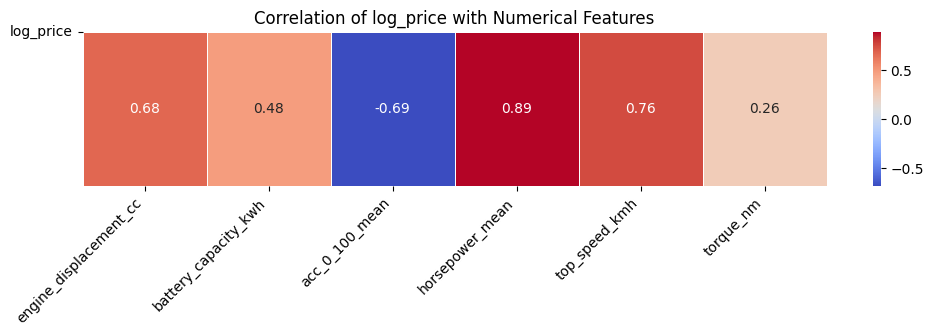

In [0]:
import numpy as np  # Correlation of each numerical feature with log_price

df_eda["log_price"] = np.log1p(df_eda["price_usd"])

# Select only log_price and its correlated variables
corr_matrix = df_eda[num_cols_log].corr()
corr_subset = corr_matrix.loc["log_price", num_cols_log[:-1]].to_frame().T

plt.figure(figsize=(12, 2))
sns.heatmap(
    corr_subset,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation of log_price with Numerical Features")
plt.yticks([0], ["log_price"], rotation=0)
plt.xticks(rotation=45, ha="right")
plt.show()